# **Download Wave Buoy Data from the U.S. National Data Buoy Center (NDBC)**

---


Data is retrieved from the **National Data Buoy Center (NDBC)**:
🔗 [https://www.ndbc.noaa.gov/](https://www.ndbc.noaa.gov/)

This notebook downloads and visualizes **all available historical years** of wave buoy data for a single Oregon station (buoy **46050**, Stonewall Bank, offshore Newport, OR):

- **Bulk wave parameters** → time series
- **Density energy spectrum** → final average spectrum, plotted and saved
- **Directional wave spectrum** → final average directional spectrum, plotted and saved

The available years are discovered automatically from NDBC's station history page, so no year range needs to be hardcoded.

📘 **Reference documentation:**
- [NDBC Web Data Guide](https://www.ndbc.noaa.gov/docs/ndbc_web_data_guide.pdf)
- [NDBC Station Map](https://www.ndbc.noaa.gov/)
- [Measurement Descriptions & Units](https://www.ndbc.noaa.gov/faq/measdes.shtml)


---


<summary><strong>📥 Bulk Wave Parameters</strong></summary>

Downloads and plots the full time series (significant wave height, period, direction) for the buoy.

---


<summary><strong>🌊 Density Energy Spectrum</strong></summary>

Downloads the yearly wave energy spectra and plots the **final, frequency-averaged spectrum** across all available years. The figure is saved as a PNG.

📘 **More info:** [Wave Spectra Description](https://www.ndbc.noaa.gov/faq/wavespectra.shtml)


---


<summary><strong>🧭 Directional Wave Spectrum</strong></summary>

Reconstructs and plots the **final average directional spectrum** from the Fourier coefficient files. The directional spectrum is:

\begin{align*}
S(f, A) = C_{11}(f) \cdot D(f, A)
\end{align*}

Where:

- \( C_11 \) = Spectral Wave Density
- \( f \) = frequency (Hz)
- \( A \) = azimuth angle (°), measured clockwise from true North (direction **waves come from**)
- \( D(f, A): directional distribution function \) is defined as:

\begin{align*}
D(f, A) = \frac{1}{\pi} \left[ 0.5 + R_1 \cos(A - \alpha_1) + R_2 \cos\left(2(A - \alpha_2)\right) \right]
\end{align*}


- alpha1 → "mean wave direction"
- alpha2 → "principal wave direction"
- r1 → "first normalized directional moment" 
- r2 → "second normalized directional moment"



📘 **Further Reading:**
Earle, Steele & Wang (1999). *Use of advanced directional wave spectra analysis methods*. Ocean Engineering, 26(12), 1421–1434.


---


In [1]:
from bluemath_tk.downloaders.noaa.noaa_downloader import NOAADownloader

from utils.ndbc_data import get_available_years, select_years

noaa_downloader = NOAADownloader(
    base_path_to_download="./noaa_data", debug=True, check=False
)

In [2]:
# Downloading and plotting Buoy Bulk parameters time-series

# Outputs:
# All outputs are saved in an auto-generated folder named buoy_id.
# buoy_id_bulk_parameters.csv: Time-series of the downloaded bulk parameters (all available years).


buoy_id = "46050"  # Stonewall Bank, Oregon

# Choose which years to download:
#   "single" -> just one year          (set single_year)
#   "period" -> a range of years       (set start_year / end_year, inclusive)
#   "all"    -> every year available in NDBC's historical archive

download_mode = "single"  # "single" | "period" | "all"

single_year = 2020
start_year = 1991
end_year = 2025

available_years = get_available_years(buoy_id, subdir="stdmet", suffix="h")
years = select_years(
    available_years,
    download_mode,
    buoy_id,
    "year(s) selected",
    single_year,
    start_year,
    end_year,
)

# The selected years are merged and saved into a single CSV per buoy
# (overwritten on every call), so it always matches the selected years.
download_result = noaa_downloader.download_data(
    data_type="bulk_parameters",
    buoy_id=buoy_id,
    years=years,
)
print(download_result)

# download_data only saves the CSV and returns a status message, so we read it back.
# The merged CSV already holds every selected year: read it once (passing a single
# year) to avoid loading the same file once per year.
buoy_df = (
    noaa_downloader.read_bulk_parameters(buoy_id=buoy_id, years=years[0])
    .drop_duplicates()
    .reset_index(drop=True)
)
buoy_df

Buoy 46050: 1 year(s) selected -> [2020]
Data saved to ./noaa_data/buoy_data/46050/buoy_46050_bulk_parameters.csv


,YYYY,MM,DD,hh,mm,WD,WSPD,GST,WVHT,DPD,APD,MWD,BAR,ATMP,WTMP,DEWP,VIS,TIDE,datetime
0,2020,1,1,0,0,200,10.7,13.3,99.00,99.00,99.00,999,1017.2,10.6,10.6,9.7,99.0,99.0,2020-01-01 00:00:00
1,2020,1,1,0,10,202,10.4,12.3,99.00,99.00,99.00,999,1016.8,10.6,10.6,9.7,99.0,99.0,2020-01-01 00:10:00
2,2020,1,1,0,20,198,10.6,13.4,99.00,99.00,99.00,999,1016.4,10.6,10.6,9.7,99.0,99.0,2020-01-01 00:20:00
3,2020,1,1,0,30,194,11.0,13.8,99.00,99.00,99.00,999,1015.8,10.6,10.6,9.7,99.0,99.0,2020-01-01 00:30:00
4,2020,1,1,0,40,194,11.2,14.1,3.90,12.12,7.66,269,1015.2,10.6,10.6,9.7,99.0,99.0,2020-01-01 00:40:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52206,2020,12,31,23,10,199,6.6,8.9,99.00,99.00,99.00,999,1020.7,999.0,10.4,999.0,99.0,99.0,2020-12-31 23:10:00
52207,2020,12,31,23,20,195,6.6,8.5,99.00,99.00,99.00,999,1020.6,999.0,10.3,999.0,99.0,99.0,2020-12-31 23:20:00
52208,2020,12,31,23,30,195,6.5,8.7,99.00,99.00,99.00,999,1020.6,999.0,10.3,999.0,99.0,99.0,2020-12-31 23:30:00
52209,2020,12,31,23,40,198,6.5,8.4,4.44,12.90,9.29,315,1020.6,999.0,10.3,999.0,99.0,99.0,2020-12-31 23:40:00


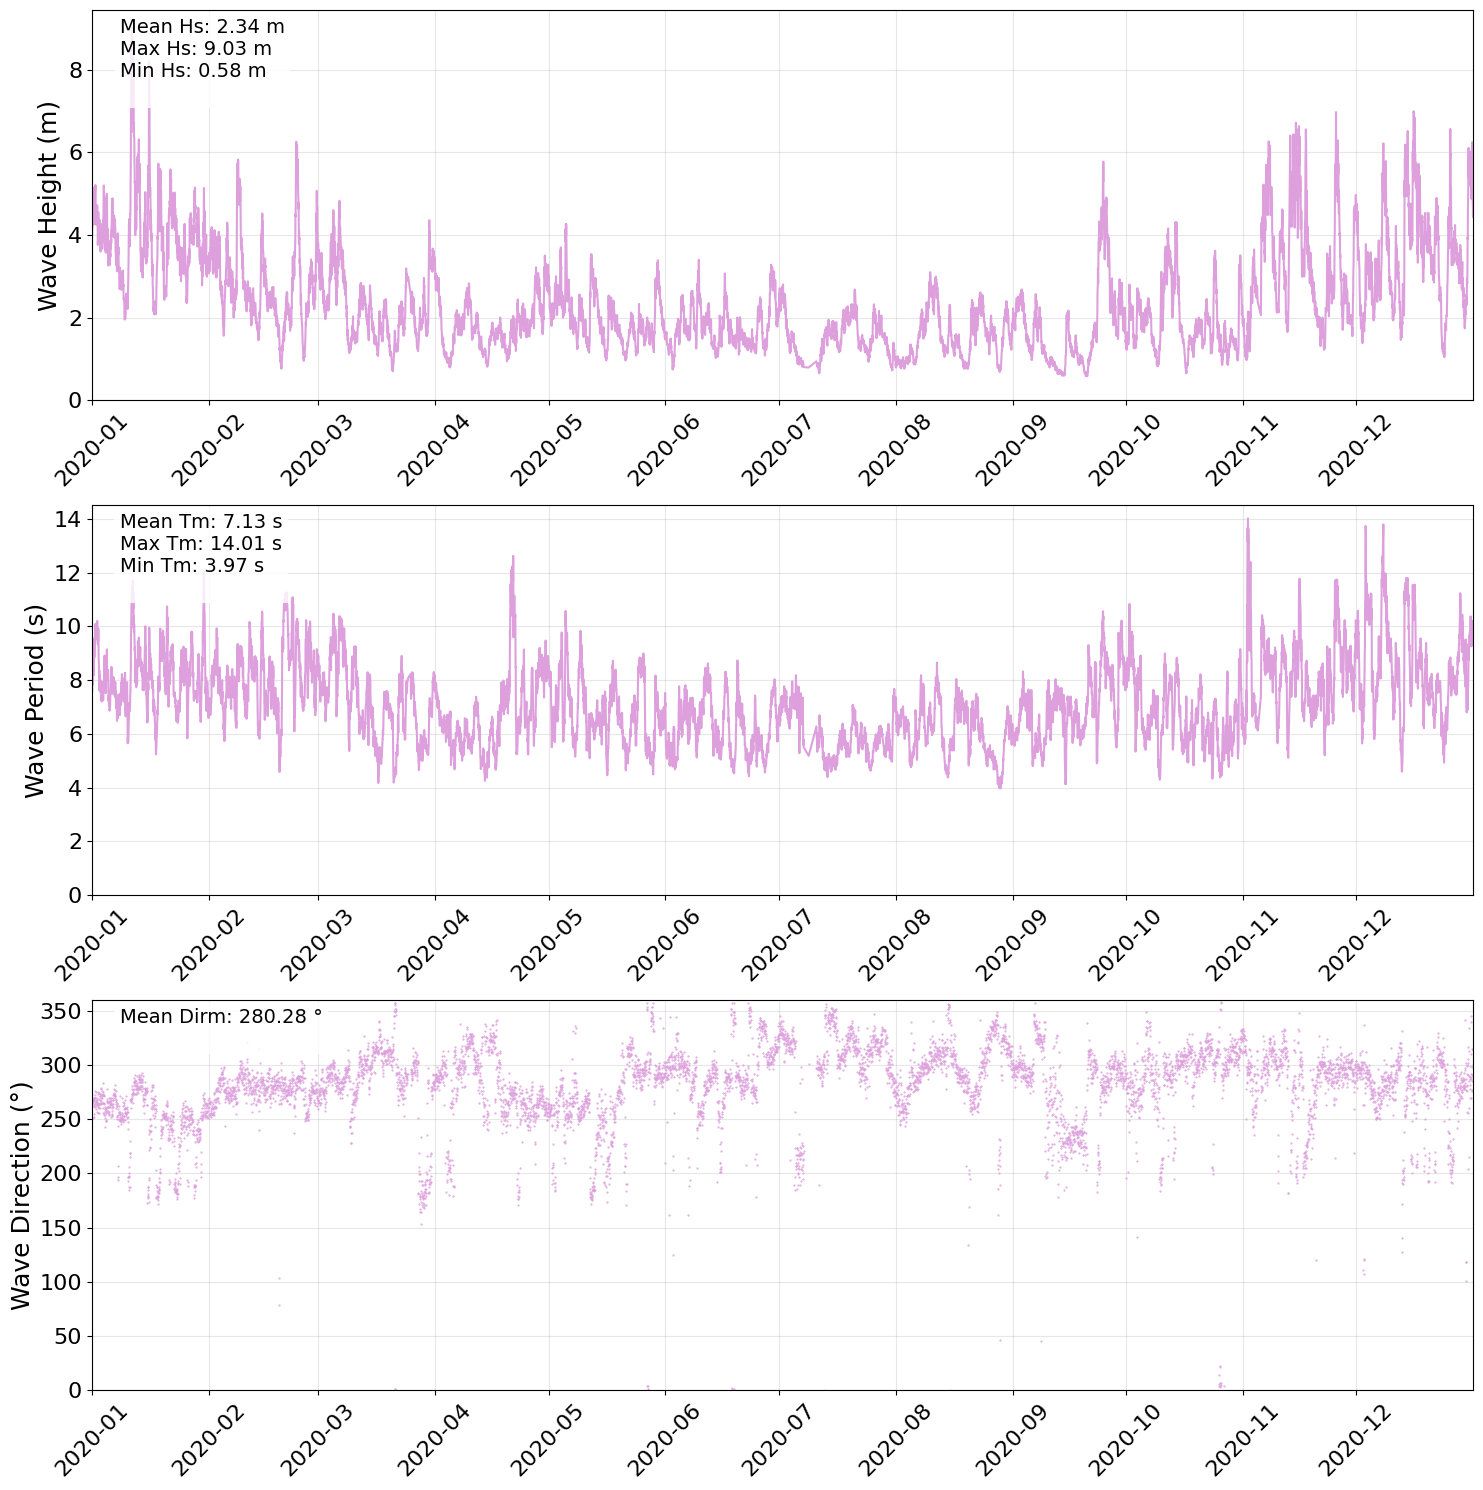

In [3]:
from utils.ndbc_plotting import plot_bulk_timeseries

_fig = plot_bulk_timeseries(buoy_df)

Buoy 46050: 1 years of spectra selected -> [2020]
Downloaded 1 files for wave spectra
Saved average spectrum to ./noaa_data/buoy_data/46050/figures/average_spectrum_46050_2020_2020.png


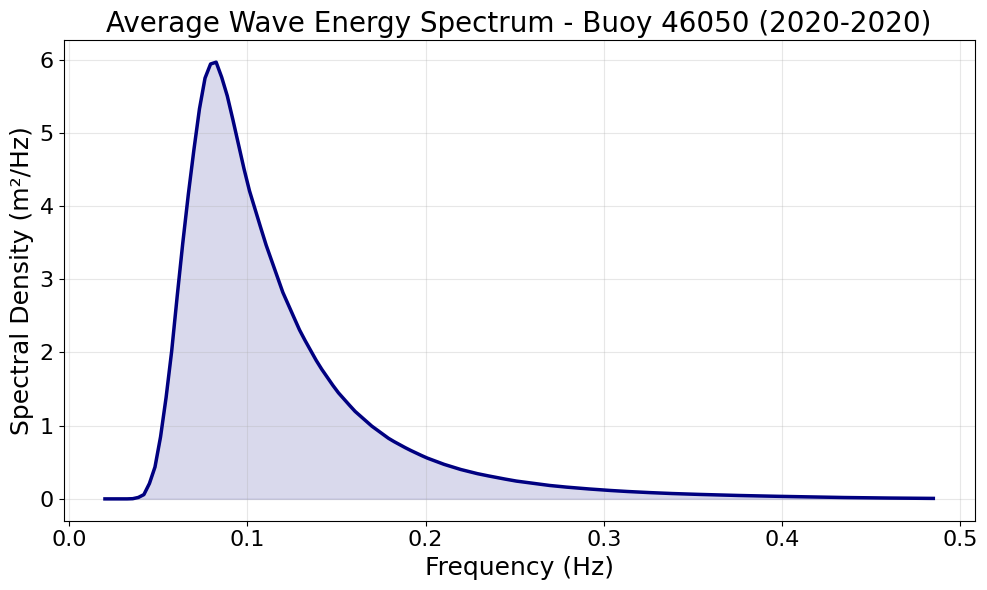

In [4]:
# Downloading and plotting the Buoy Wave Energy Spectrum
# Outputs:
# Generates a folder (buoy_id/wave_spectra) with the wave energy spectra CSV per year.
# average_spectrum_buoy_id_start_year_end_year.png (in buoy_id/figures): the final,
# frequency-averaged spectrum across the selected period.

import os

from utils.ndbc_plotting import plot_average_spectrum

spec_years_available = get_available_years(buoy_id, subdir="swden", suffix="w")
spec_years = select_years(
    spec_years_available,
    download_mode,
    buoy_id,
    "years of spectra selected",
    single_year,
    start_year,
    end_year,
)

print(
    noaa_downloader.download_data(
        data_type="wave_spectra",
        buoy_id=buoy_id,
        years=spec_years,
    )
)

# download_data: only saves the CSV file(s) and returns a status message,
# so we read the saved CSV(s) to get the actual data
spec_df = noaa_downloader.read_wave_spectra(buoy_id=buoy_id, years=spec_years)

fig = plot_average_spectrum(spec_df, buoy_id=buoy_id)

figures_dir = os.path.join(
    noaa_downloader.base_path_to_download, "buoy_data", buoy_id, "figures"
)
os.makedirs(figures_dir, exist_ok=True)
spectrum_path = os.path.join(
    figures_dir, f"average_spectrum_{buoy_id}_{spec_years[0]}_{spec_years[-1]}.png"
)
fig.savefig(spectrum_path, dpi=150, bbox_inches="tight")
print(f"Saved average spectrum to {spectrum_path}")

In [5]:
# Downloading Directional Wave Spectra coefficient files
# Outputs:
# Creates a folder buoy_id/directional_spectra containing the downloaded coefficient files
# (alpha1, alpha2, r1, r2, c11) per year, required for spectral reconstruction.

from utils.ndbc_data import get_available_directional_years

# Only keep years where all four coefficients (alpha1, alpha2, r1, r2) are available
direc_years_available = get_available_directional_years(buoy_id)
direc_years = select_years(
    direc_years_available,
    download_mode,
    buoy_id,
    "years of directional coefficients selected",
    single_year,
    start_year,
    end_year,
)

print(
    noaa_downloader.download_data(
        data_type="directional_spectra",
        buoy_id=buoy_id,
        years=direc_years,
    )
)

# download_data: only saves the raw files and returns a status message,
# so we read the saved files to get (alpha1, alpha2, r1, r2, c11)
direc_df = noaa_downloader.read_directional_spectra(
    buoy_id=buoy_id,
    years=direc_years,
)
direc_df

Buoy 46050: 1 years of directional coefficients selected -> [2020]
Downloaded 5 coefficient files


(                     0.0200  0.0325  0.0375  0.0425  0.0475  0.0525  0.0575  \
 2020-01-01 00:40:00   121.0   124.0   298.0   270.0   251.0   242.0   309.0   
 2020-01-01 01:40:00   341.0   319.0   250.0   259.0   260.0    46.0   305.0   
 2020-01-01 02:40:00    83.0   149.0   324.0   282.0   266.0   245.0   239.0   
 2020-01-01 03:40:00   297.0   298.0   186.0   223.0   239.0   244.0   238.0   
 2020-01-01 04:40:00   261.0   204.0   104.0   264.0   261.0   213.0   287.0   
 ...                     ...     ...     ...     ...     ...     ...     ...   
 2020-12-31 19:40:00     7.0    68.0   254.0    59.0    20.0   221.0   222.0   
 2020-12-31 20:40:00    44.0   138.0   306.0   320.0    31.0   190.0   325.0   
 2020-12-31 21:40:00    39.0    65.0    11.0    74.0   342.0   323.0   288.0   
 2020-12-31 22:40:00   177.0   221.0    19.0    35.0    82.0   336.0   308.0   
 2020-12-31 23:40:00   151.0   212.0    66.0   137.0   154.0   145.0   152.0   
 
                      0.0625  0.0675  

Saved average directional spectrum to ./noaa_data/buoy_data/46050/figures/average_directional_spectrum_46050_2020_2020.png


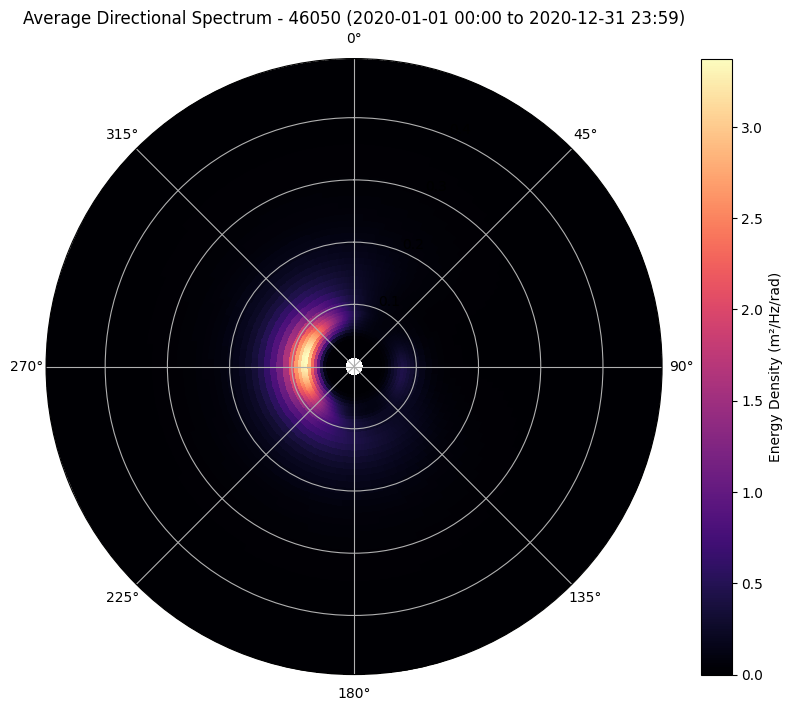

In [6]:
# Plotting the final average directional spectrum over the full downloaded period.
# Saved as average_directional_spectrum_buoy_id_start_year_end_year.png in buoy_id/figures.

# Reload helpers so rerunning this cell picks up the alignment fix.
import importlib
from utils import ndbc_data, ndbc_plotting
importlib.reload(ndbc_data)
importlib.reload(ndbc_plotting)
from utils.ndbc_plotting import plot_average_directional_spectrum

start_date = f"{direc_years[0]}-01-01 00:00"
end_date = f"{direc_years[-1]}-12-31 23:59"

alpha1_df, alpha2_df, r1_df, r2_df, c11_df = (
    direc_df_elem.loc[start_date:end_date] for direc_df_elem in direc_df
)

fig = plot_average_directional_spectrum(
    alpha1_df, alpha2_df, r1_df, r2_df, c11_df, buoy_id, start_date, end_date
)

direc_spectrum_path = os.path.join(
    figures_dir,
    f"average_directional_spectrum_{buoy_id}_{direc_years[0]}_{direc_years[-1]}.png",
)
fig.savefig(direc_spectrum_path, dpi=150, bbox_inches="tight")
print(f"Saved average directional spectrum to {direc_spectrum_path}")

### Directional spectrum reconstruction

The truncated Fourier series used for $D(f, A)$ can become **negative** in the
directions opposite to the main wave direction when $r_1$, $r_2$ are large
(narrow, swell-dominated seas). Those negative lobes are not physical and are
set to zero.


In [12]:
# Building and saving the full directional wave spectrum in the offshore_spectra
# format (dims: time, freq, dir; variable: efth; scalar coords: latitude, longitude).
# The frequency and direction bins come from the downloaded NDBC data.

import os
import numpy as np
import xarray as xr

from utils.ndbc_data import align_directional_coefficients, build_directional_spectrum_dataset, integrate_dir_periodic
from utils.ndbc_data import get_station_coords, save_netcdf


buoy_lat, buoy_lon = get_station_coords(buoy_id)

ds_out = build_directional_spectrum_dataset(
    alpha1_df, alpha2_df, r1_df, r2_df, c11_df, buoy_lat, buoy_lon,
)

ds_out["efth"] = (
    ds_out["efth"]
    .rolling(freq=5, dir=5, center=True, min_periods=1)
    .mean()
)

# Save the final directional wave spectrum in NetCDF format, with compression.
# The filename encodes the buoy location (lat/lon) and the covered date range,
# all separated by underscores.
output_filename = (
    f"offshore_spectra_{buoy_lat:.3f}_{buoy_lon:.3f}"
    f"_{direc_years[0]}0101_{direc_years[-1]}1231.nc"
)
output_path = os.path.join("outputs", output_filename)
save_netcdf(ds_out, output_path, encoding={"efth": {"zlib": True, "complevel": 4}})

print(f"Saved offshore spectra {dict(ds_out.sizes)} to {output_path}")
ds_out

Saved offshore spectra {'time': 8621, 'freq': 47, 'dir': 72} to outputs/offshore_spectra_44.679_-124.535_20200101_20201231.nc


<xarray.Dataset> Size: 233MB
Dimensions:    (time: 8621, freq: 47, dir: 72)
Coordinates:
  * time       (time) datetime64[ns] 69kB 2020-01-01T00:40:00 ... 2020-12-31T...
  * freq       (freq) float64 376B 0.02 0.0325 0.0375 ... 0.445 0.465 0.485
  * dir        (dir) int64 576B 0 5 10 15 20 25 30 ... 330 335 340 345 350 355
    latitude   float64 8B 44.68
    longitude  float64 8B 235.5
Data variables:
    efth       (time, freq, dir) float64 233MB 0.0 0.0 ... 6.066e-06 5.68e-06

### Validation: reconstructed Hs vs the buoy's own WVHT

Sanity check for the reconstruction: integrate the saved directional spectrum
(`efth`, m²/Hz/deg) over frequency and (periodic) direction to recover the zero-th
spectral moment `m0`, then `Hs = 4*sqrt(m0)`, and compare it against `WVHT`
from the bulk parameters file (the buoy's own, independently computed,
significant wave height). Close agreement (correlation ~1, small bias) means
the frequency/direction bookkeeping in the reconstruction is consistent; a
large or systematic mismatch would flag a units/alignment problem.


Hs reconstructed vs buoy WVHT (46050, 8621 matched records) -> bias: +0.008 m | correlation: 0.9997


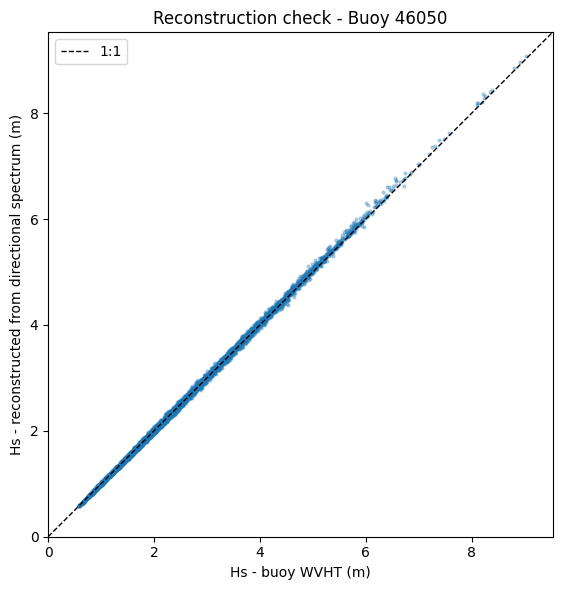

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

m0 = integrate_dir_periodic(ds_out["efth"]).integrate("freq")
hs_recon = 4 * np.sqrt(m0)

def unique_hs_by_time(series, name):
    """Keep one valid value per timestamp; reject contradictory observations."""
    series = pd.to_numeric(series, errors="coerce").replace([np.inf, -np.inf], np.nan)
    series.index = pd.DatetimeIndex(series.index)
    series = series.loc[series.index.notna()]
    grouped = series.groupby(level=0, sort=True)
    conflicts = grouped.nunique(dropna=True) > 1
    if conflicts.any():
        raise ValueError(f"{name}: conflicting Hs values at {int(conflicts.sum())} timestamps.")
    repeats = int(series.index.duplicated().sum())
    if repeats:
        print(f"{name}: merged {repeats} duplicate rows, retaining the first non-missing value.")
    return grouped.first().rename(name)


wvht = buoy_df.set_index("datetime")["WVHT"].replace(99.0, np.nan)
wvht = unique_hs_by_time(wvht, "Hs_buoy_WVHT")
hs_reconstructed = unique_hs_by_time(hs_recon.to_series(), "Hs_reconstructed")
hs_check = pd.concat([hs_reconstructed, wvht], axis=1, join="inner").dropna()
if hs_check.empty:
    raise ValueError("No valid Hs pairs at shared timestamps.")

bias = (hs_check["Hs_reconstructed"] - hs_check["Hs_buoy_WVHT"]).mean()
corr = hs_check["Hs_reconstructed"].corr(hs_check["Hs_buoy_WVHT"])
print(
    f"Hs reconstructed vs buoy WVHT ({buoy_id}, {len(hs_check)} matched records) "
    f"-> bias: {bias:+.3f} m | correlation: {corr:.4f}"
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(hs_check["Hs_buoy_WVHT"], hs_check["Hs_reconstructed"], s=4, alpha=0.3)
lims = [0, hs_check.to_numpy().max() * 1.05]
ax.plot(lims, lims, "k--", linewidth=1, label="1:1")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("Hs - buoy WVHT (m)")
ax.set_ylabel("Hs - reconstructed from directional spectrum (m)")
ax.set_title(f"Reconstruction check - Buoy {buoy_id}")
ax.legend()
plt.tight_layout()

m0 raw: 0.4332  m0 smoothed: 0.4370  ratio: 1.0089


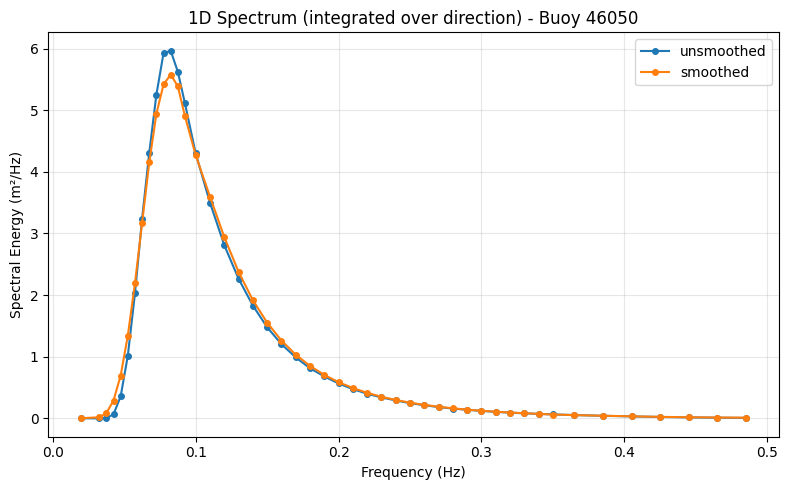

In [14]:
ds_out_raw = build_directional_spectrum_dataset(
    alpha1_df, alpha2_df, r1_df, r2_df, c11_df, buoy_lat, buoy_lon,
)

spec1d_raw = integrate_dir_periodic(ds_out_raw["efth"]).mean(dim="time")
spec1d_smooth = integrate_dir_periodic(ds_out["efth"]).mean(dim="time")

m0_raw = np.trapz(spec1d_raw.values, ds_out["freq"].values)
m0_smooth = np.trapz(spec1d_smooth.values, ds_out["freq"].values)
print(f"m0 raw: {m0_raw:.4f}  m0 smoothed: {m0_smooth:.4f}  ratio: {m0_smooth / m0_raw:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ds_out["freq"].values, spec1d_raw.values, "o-", label="unsmoothed", markersize=4)
ax.plot(ds_out["freq"].values, spec1d_smooth.values, "o-", label="smoothed", markersize=4)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Spectral Energy (m²/Hz)")
ax.set_title(f"1D Spectrum (integrated over direction) - Buoy {buoy_id}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

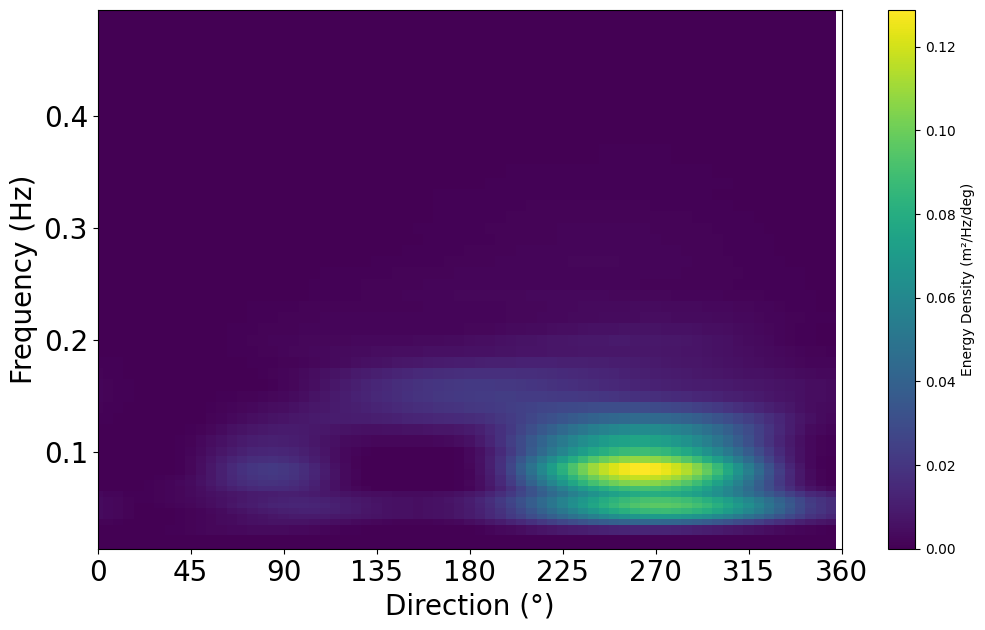

In [15]:
import matplotlib.pyplot as plt
import numpy as np

efth_mean = ds_out["efth"].mean(dim="time")

fig, ax = plt.subplots(figsize=(12, 7))
pcm = ax.pcolormesh(
    ds_out["dir"].values,
    ds_out["freq"].values,
    ds_out.sel(time=ds_out.time[12]).efth.values,
    cmap="viridis",
    shading="nearest",
)
fig.colorbar(pcm, ax=ax, label="Energy Density (m²/Hz/deg)")

ax.set_xlabel("Direction (°)", fontsize=20)
ax.set_ylabel("Frequency (Hz)", fontsize=20)

ax.set_xlim(0, 360)
ax.set_xticks(np.arange(0, 361, 45))
ax.tick_params(axis="both", labelsize=20)